In [27]:
import numpy as np


class MyKNN:

    def __init__(self, k_value=3):
        self.k = k_value

    def fit(self, Xtr, ytr): #Xtr is a list of vectors, ytr is a list of integers
        self.X = Xtr
        self.y = ytr
        self.classes = list(np.unique(ytr))
        self.trainExamples, self.featDim = np.asarray(Xtr).shape
        #TODO: Sanity check of data X and labels y


    @staticmethod
    def euclideanDistance(a,b):
        distance = 0
        for i,j in zip(a,b):
            distance += (i-j) * (i-j)
            
        return np.sqrt(distance)
        #TODO: Check length of vectors a ans b 


    def predict(self, X):
        out = [] 
        for vec in X:
            out.append(self.predict_vec(vec))
        return(np.asarray(out))


    def predict_vec(self, x):
        dist = []
        counts = np.zeros(len(self.classes))
        for t in range(self.trainExamples):
            distance = self.euclideanDistance(x, self.X[t])
            dist.append((distance, t))

        dist.sort(key = lambda cal:cal[0])

        for d,idx in dist[:self.k]:
            counts[self.y[idx]] = counts[self.y[idx]] + 1

        return(np.argmax(counts))
            

In [28]:
knn = MyKNN()

X = np.asarray([[0, 2], [1, 2], [5, 1], [6, 2]])
y = np.asarray([0, 0, 1, 1])
X.shape

(4, 2)

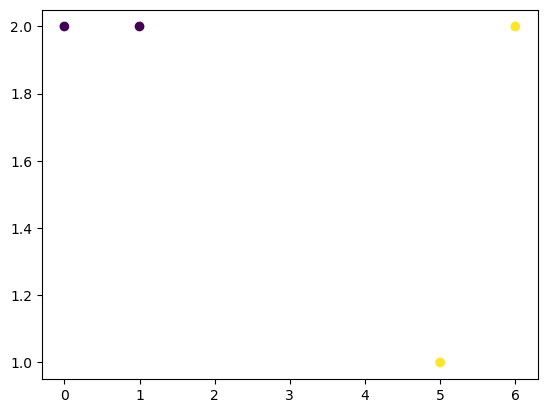

In [29]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.show()

In [30]:
knn.fit(X, y)

In [32]:
X_new = np.asarray([[1, 1.8], [4, 0], [6, 1], [3, 2]])

prediction = knn.predict(X_new) # should predict [0, 1, 1, 0]
prediction

array([0, 1, 1, 0])

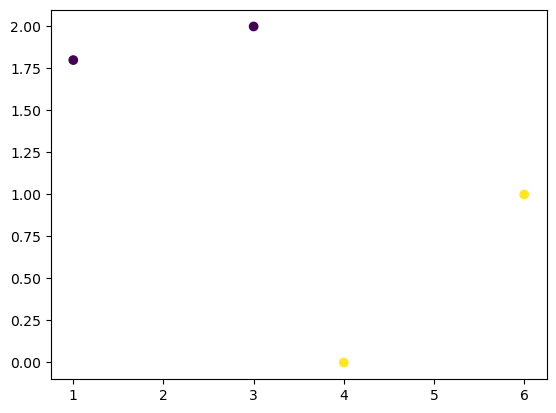

In [34]:
plt.scatter(x=X_new[:, 0], y=X_new[:, 1], c=prediction)
plt.show()